In [1]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [111]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('sqrtka_ext', np.sqrt(1e6*2*pi)) # in MHz
sim.add_param('ka_int', 1e6*2*pi) # in MHz
sim.add_param('g4', -1e6 * 2 * np.pi)
sim.add_paramsweep('amplR', 0, 100, 101)
sim.add_param('wa', 5.0e9*2*pi, is_excitation=True)
sim.add_paramsweep('wR', -0.05e9 * 2 * np.pi, 0.05e9 * 2 * np.pi, 101)
sim.add_param('rampR', 10e-9)
sim.add_param('startR', 100e-9)
sim.add_param('stopR', 900e-9)
sim.add_param('phaseR', 0)

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')

sim.add_EOM('ain', Rpulse)

sim.add_EOM('a', '- ain*sqrtka_ext**2 - (sqrtka_ext**2 + ka_int)/2*a - 1j*a*g4*abs(a)**2 ')
sim.set_solve_type('all')

sim.specify_time(t_f=1e-6, pts=20001)

sim.validate()

print(amplR_f)

Recent change to specify_time(), check implementation
Simulation validation success!
17381.449986274954


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


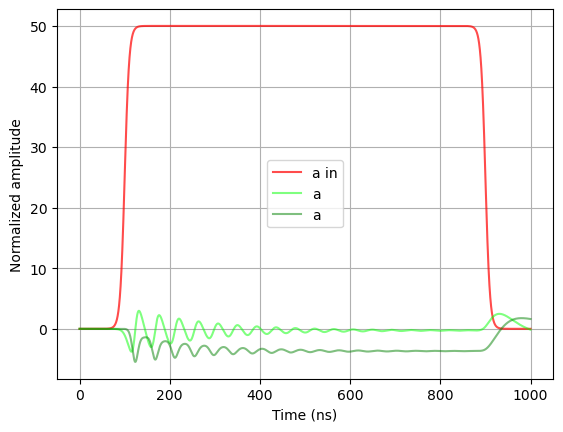

In [117]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:],color=(1,0,0,0.7),label='a in')
plt.plot(t*1e9, x[2,:],color=(0,1,0,0.5),label='a')
plt.plot(t*1e9, x[3,:],color=(0,0.5,0,0.5),label='a')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [118]:
x, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|██████████████████████████████████████████████████████████████████████████| 20001/20001 [00:09<00:00, 2113.91it/s]


 
...finished GPU solve!


In [121]:
xd = x.copy()
td = t.copy()

ain = xd[0,:]+1j*xd[1,:]
a = xd[2,:]+1j*xd[3,:]

aout = ain + sim.param_dict['sqrtka_ext']*a

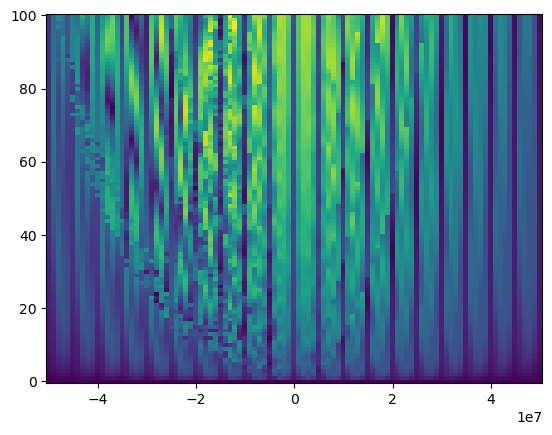

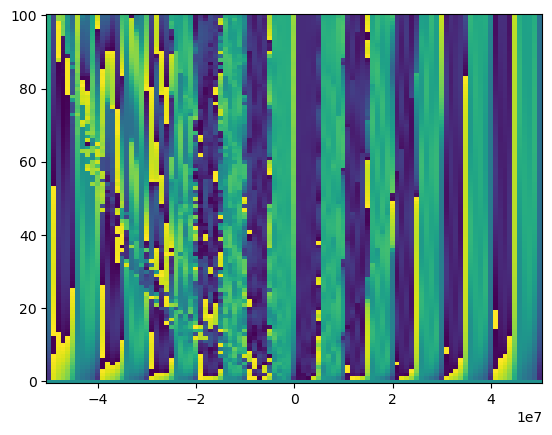

In [123]:
wR = sim.paramsweep_dict['wR']/(2*np.pi)
amplR = sim.paramsweep_dict['amplR']

plt.pcolor(wR, amplR, np.abs(aout[:,:,-1]))
plt.show()
plt.pcolor(wR, amplR, np.angle(aout[:,:,-1]))
plt.show()

In [105]:
np.shape(t)

(101, 101, 20001)